In [2]:
import tensorflow as tf

In [3]:
# MNIST 데이터셋
(train_input, train_target), (test_input, test_target) = tf.keras.datasets.fashion_mnist.load_data() # 60,000개의 훈련용 데이터와 10,000개의 테스트 데이터


In [4]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [5]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


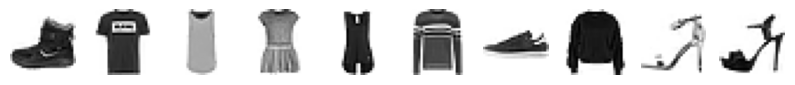

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))

for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
    
plt.show()

In [7]:
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


In [8]:
print([train_target[i] for i in range(10)]) # 훈련용 정답 데이터
# 0 : 티셔츠, 1 : 바지, 2 : 스웨터, 3 : 드레스 ...

[np.uint8(9), np.uint8(0), np.uint8(0), np.uint8(3), np.uint8(0), np.uint8(2), np.uint8(7), np.uint8(2), np.uint8(5), np.uint8(5)]


In [9]:
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


## 로지스틱 회귀 패션 아이템 분류하기

In [10]:
# 정규화
train_scaled = train_input / 255.0 # / 255.0 -> 0, 1사이의 값으로 매칭되게 변환

# 입력데이터: 2 dim -> 1 dim 변환
# 첫번째 차원은 변하지 않고 원본 데이터의 두번째, 세번째 차원이 1차원으로 합쳐짐
train_scaled = train_scaled.reshape(-1, 28*28)  # 3차원 데이터 -> 2차원 데이터로 변환 : 28*28 = 784
print(train_scaled.shape) # 한 차원 낮아진 데이터 

print(train_input.shape)


(60000, 784)
(60000, 28, 28)


In [12]:
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=30, random_state=42)  # max_iter=10 : 반복횟수

scores = cross_validate(sc, train_scaled, train_target, n_jobs = -1)  # cross_validate 교차 검증법
print(np.mean(scores['test_score']))

0.8429666666666666
